In [7]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone
from extractor.alp_extractor import ALPExtractor
from CFA.cfa import CFA as cfa

In [8]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()
alp = ALPExtractor()

In [9]:
holding_period = 5
tickers = sp500["ticker"].values
positions = 10
hedge_percentage = 0.05
training_year = datetime.now().year - 3
today = datetime.now()
weekday = today.weekday() - 1 if today.weekday() != 0 else 4
week = today.isocalendar()[1] if today.weekday() != 0 else today.isocalendar()[1] - 1
week_mod = int(week % (holding_period/5))
print(week_mod,week)

0 51


In [10]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        simulation = ticker_prices.copy()
        simulation.sort_values("date",inplace=True)
        simulation["historical_return"] = (simulation["adjclose"] - simulation["adjclose"].shift(100)) / simulation["adjclose"].shift(100)
        simulation["historical_volatility"] = simulation["adjclose"].rolling(100).std() / simulation["adjclose"].rolling(100).mean()
        simulation["historical_return_to_risk"] = simulation["historical_return"] / simulation["historical_volatility"]
        simulation["volatility"] = (simulation["adjclose"].rolling(holding_period).std() / simulation["adjclose"].rolling(holding_period).mean())
        simulation["current_return"] = (simulation["adjclose"] - simulation["adjclose"].shift(holding_period)) / simulation["adjclose"].shift(holding_period)
        simulation["return_to_risk"] = simulation["current_return"] / simulation["volatility"]
        simulation["expected_return"] = simulation["historical_return_to_risk"] * simulation["volatility"]
        simulation = cfa.cfa(simulation,holding_period)
        simulation["buy_price"] = simulation["adjclose"]
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"] + timedelta(days=int(holding_period /5) * 7)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"] * (1/positions) *0.99
        simulation["return"] = [max(float(-hedge_percentage/positions),x) for x in simulation["return"]]
        prices.append(simulation)
    except Exception as e:
        print(ticker,str(e))
        continue
market.disconnect()

model_prep:  12%|███████████████▍                                                                                                             | 62/503 [00:29<03:21,  2.19it/s]

BRK.B 'date'


model_prep:  16%|███████████████████▍                                                                                                         | 78/503 [00:36<02:50,  2.50it/s]

BF.B 'date'
BLDR 'date'


model_prep:  52%|█████████████████████████████████████████████████████████████████                                                           | 264/503 [02:23<01:40,  2.39it/s]

JBL 'date'


model_prep:  90%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏           | 455/503 [03:47<00:20,  2.38it/s]

UBER 'date'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [04:08<00:00,  2.02it/s]

ZTS 'date'


In [11]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")
fed.connect()
bench = fed.retrieve("sp500")
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
fed.disconnect()
trades = sim[sim["weekday"]==weekday].copy()
trades = trades[trades["week"] % int(holding_period/5) == week_mod]
trades = processor.column_date_processing(trades)

In [12]:
## backtest
valuation_methods = ["excess_return"
                     ,"historical_return"
                     ,"historical_volatility"
                     ,"historical_return_to_risk"
                     ,"volatility"
                     ,"current_return"
                     ,"return_to_risk"
                     ,"expected_return"]
reports = []
for valuation_method in tqdm(valuation_methods):
    try:
        iteration_trades = trades.copy().sort_values(valuation_method,ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
        portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
        portfolio.sort_values("date",inplace=True)
        portfolio["year"] = [x.year for x in portfolio["date"]]
        portfolio = portfolio[(portfolio["date"]<portfolio["date"].max()) & (portfolio["year"]>=training_year)]
        portfolio["return"] = portfolio["return"] + 1
        portfolio["cumulative_return"] = portfolio["return"].cumprod()
        portfolio = processor.column_date_processing(portfolio)
        portfolio = processor.merge(portfolio,bench.copy(),on="date")
        portfolio.dropna(inplace=True)
        portfolio["bench_cum_return"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1
        portfolio["beta"] = portfolio["cumulative_return"].cov(portfolio["value"])
        portfolio["treynor"] = portfolio["cumulative_return"] / portfolio["beta"]
        portfolio["excess_return"] = portfolio["cumulative_return"] - portfolio["bench_cum_return"]
        portfolio["valuation_method"] = valuation_method
        reports.append(portfolio[["valuation_method","excess_return"]].tail(1))
    except Exception as e:
        print(str(e))
        continue

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:03<00:00,  2.23it/s]


In [13]:
report = pd.concat(reports)

In [14]:
report.sort_values("excess_return",ascending=False)

,valuation_method,excess_return
203,historical_volatility,54.339845
203,volatility,23.082398
203,historical_return,18.333286
203,expected_return,7.254933
203,excess_return,7.090958
203,current_return,6.431550
203,historical_return_to_risk,3.028118
203,return_to_risk,1.835115


In [15]:
valuation_method = "historical_volatility"

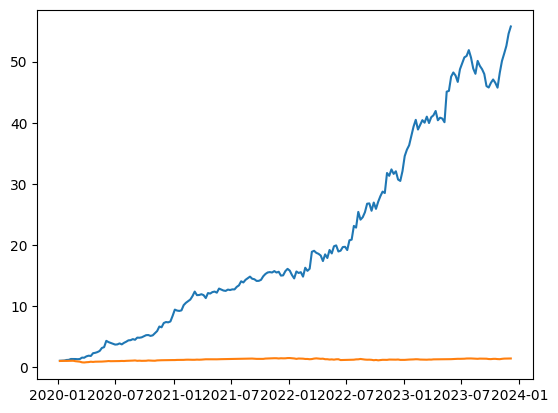

In [16]:
iteration_trades = trades.copy().sort_values(valuation_method,ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
iteration_trades = iteration_trades[["date","sell_date","ticker","adjclose","buy_price","sell_price",valuation_method,"return"]]
portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio["year"] = [x.year for x in portfolio["date"]]
portfolio = portfolio[(portfolio["date"]<portfolio["date"].max()) & (portfolio["year"]>=training_year)]
portfolio["return"] = portfolio["return"]  + 1
portfolio["cumulative_return"] = portfolio["return"].cumprod()
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench.copy(),on="date")
portfolio.dropna(inplace=True)
portfolio["bench_cum_return"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1
portfolio["excess_return"] = portfolio["cumulative_return"] - portfolio["bench_cum_return"]
recommendations = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method]].sort_values(["date"]).tail(positions)
plt.plot(portfolio["date"].values,portfolio["cumulative_return"].values)
plt.plot(portfolio["date"].values,portfolio["bench_cum_return"].values)
plt.show()

In [17]:
portfolio.sort_values("date",ascending=False)

,date,return,year,cumulative_return,quarter,month,week,weekday,realtime_start,realtime_end,value,bench_cum_return,excess_return
203,2023-12-05 00:00:00+00:00,1.021648,2023,55.750697,4,12,49,1,2023-12-10,2023-12-10,4567.18,1.410851,54.339845
202,2023-11-28 00:00:00+00:00,1.037806,2023,54.569388,4,11,48,1,2023-12-10,2023-12-10,4554.89,1.407055,53.162333
201,2023-11-21 00:00:00+00:00,1.024810,2023,52.581495,4,11,47,1,2023-12-10,2023-12-10,4538.19,1.401896,51.179599
200,2023-11-14 00:00:00+00:00,1.024081,2023,51.308537,4,11,46,1,2023-12-10,2023-12-10,4495.70,1.388770,49.919767
199,2023-11-07 00:00:00+00:00,1.040447,2023,50.102014,4,11,45,1,2023-12-10,2023-12-10,4378.38,1.352529,48.749485
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2020-02-04 00:00:00+00:00,1.017450,2020,1.184139,1,2,6,1,2023-12-10,2023-12-10,3297.59,1.018661,0.165478
3,2020-01-28 00:00:00+00:00,1.082042,2020,1.163830,1,1,5,1,2023-12-10,2023-12-10,3276.24,1.012066,0.151764
2,2020-01-21 00:00:00+00:00,1.012958,2020,1.075586,1,1,4,1,2023-12-10,2023-12-10,3320.79,1.025828,0.049758
1,2020-01-14 00:00:00+00:00,1.022271,2020,1.061827,1,1,3,1,2023-12-10,2023-12-10,3283.15,1.014201,0.047627


In [18]:
iteration_trades.sort_values("return",ascending=False).head(10)

,date,sell_date,ticker,adjclose,buy_price,sell_price,historical_volatility,return
857,2019-01-22 00:00:00+00:00,2019-01-29 00:00:00+00:00,PCG,7.700000,7.700000,13.990000,0.233141,0.080871
205,2019-10-29 00:00:00+00:00,2019-11-05 00:00:00+00:00,PCG,5.030000,5.030000,8.000000,0.359234,0.058455
47,2020-06-02 00:00:00+00:00,2020-06-09 00:00:00+00:00,OXY,14.404207,14.404207,22.636578,0.536423,0.056581
449,2020-01-28 00:00:00+00:00,2020-02-04 00:00:00+00:00,TSLA,37.793333,37.793333,59.137333,0.287513,0.055911
184,2020-03-31 00:00:00+00:00,2020-04-07 00:00:00+00:00,APA,3.955218,3.955218,6.169383,0.367820,0.055421
54,2020-06-02 00:00:00+00:00,2020-06-09 00:00:00+00:00,UAL,29.910000,29.910000,44.640000,0.523781,0.048755
963,2020-03-17 00:00:00+00:00,2020-03-24 00:00:00+00:00,CZR,10.090000,10.090000,15.050000,0.221681,0.048666
161,2019-12-03 00:00:00+00:00,2019-12-10 00:00:00+00:00,PCG,8.520000,8.520000,12.320000,0.382454,0.044155
1210,2020-02-11 00:00:00+00:00,2020-02-18 00:00:00+00:00,ENPH,39.660000,39.660000,57.220000,0.203655,0.043834
458,2019-04-30 00:00:00+00:00,2019-05-07 00:00:00+00:00,ENPH,10.040000,10.040000,14.210000,0.286364,0.041119


In [19]:
recommendations

,date,sell_date,ticker,adjclose,historical_volatility
1434,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,PODD,214.61,0.189162
1174,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,PAYC,207.98,0.206665
1915,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,ENPH,135.32,0.165293
928,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,ALGN,268.31,0.225849
1209,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,FMC,60.98,0.203658
2098,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,HAS,51.38,0.159890
2213,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,DG,130.02,0.155000
1528,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,ALB,148.93,0.184159
1184,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,ILMN,139.53,0.205625
2101,2023-12-19 00:00:00+00:00,2023-12-26 00:00:00+00:00,MRNA,89.09,0.159756


In [28]:
db.connect()
db.drop('portfolio')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",iteration_trades)
db.store("recommendations",recommendations)
db.disconnect()